In [7]:
import pandas as pd

df = pd.read_csv("../data/processed/cota_2024_features.csv")

# Estimate fuel effect again
from sklearn.linear_model import LinearRegression

fuel_model = LinearRegression()

X_fuel = df[["FuelLoadProxy"]]
y_fuel = df["LapTimeSec"]

fuel_model.fit(X_fuel, y_fuel)

fuel_slope = fuel_model.coef_[0]

# Create fuel corrected lap
df["FuelCorrectedLap"] = df["LapTimeSec"] - fuel_slope * df["FuelLoadProxy"]

# Compute driver average pace
driver_avg = df.groupby("Driver")["FuelCorrectedLap"].mean()

baseline = driver_avg.mean()

driver_delta = driver_avg - baseline

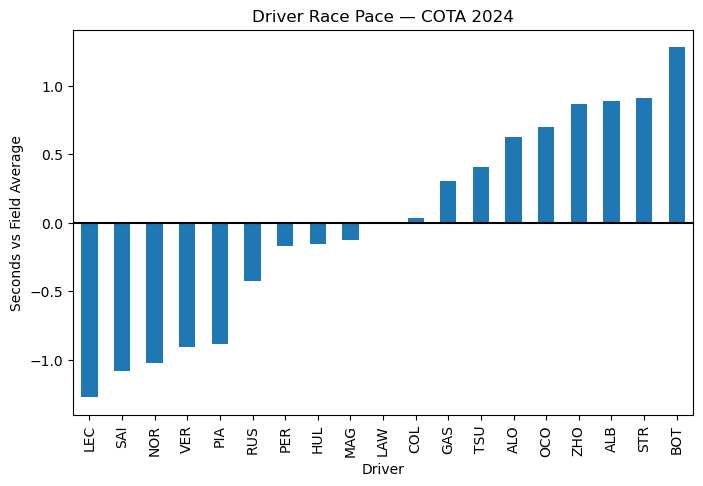

In [11]:
import matplotlib.pyplot as plt

driver_delta_sorted = driver_delta.sort_values()

plt.figure(figsize=(8,5))
driver_delta_sorted.plot(kind="bar")

plt.title("Driver Race Pace — COTA 2024")
plt.ylabel("Seconds vs Field Average")
plt.xlabel("Driver")

plt.axhline(0, color="black")

plt.show()

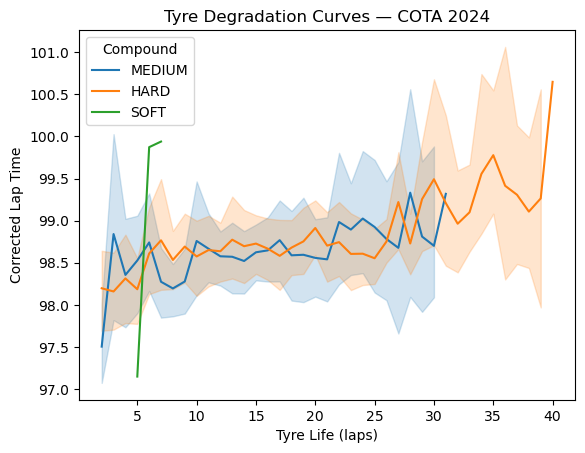

In [17]:
import seaborn as sns

sns.lineplot(
    data=df,
    x="TyreLife",
    y="FuelCorrectedLap",
    hue="Compound",
    estimator="mean"
)

plt.title("Tyre Degradation Curves — COTA 2024")
plt.xlabel("Tyre Life (laps)")
plt.ylabel("Corrected Lap Time")

plt.show()

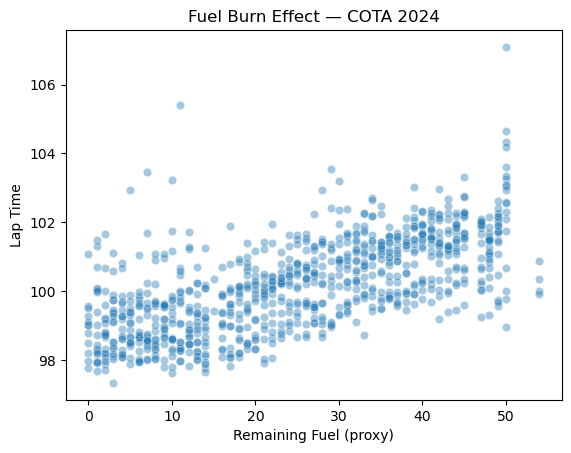

In [19]:
sns.scatterplot(
    data=df,
    x="FuelLoadProxy",
    y="LapTimeSec",
    alpha=0.4
)

plt.title("Fuel Burn Effect — COTA 2024")
plt.xlabel("Remaining Fuel (proxy)")
plt.ylabel("Lap Time")

plt.show()

- Fuel burn improves lap time by 0.060 sec per lap
- Soft tyres degrade fastest (0.066 sec per lap)
- Medium tyres show balanced performance
- Hard tyres degrade slowly (0.016 sec per lap)

Driver pace analysis shows clear performance differences across drivers.